MyModel (fitted=False, coef+interc=None+None)


Training:   0%|          | 0/200 [00:00<?, ?iter/s]

MyModel (fitted=True, coef+interc=[-27064.09236037  28245.46934965  81405.17977223   5112.89419265
   4204.33815667  54504.28909329  43748.91693429  16297.40726919
 118943.11715005  71584.08704095  34367.75740581 -76653.59934309
   9473.14798329  76136.88533643  -7158.93021889]+541204.1784709939)


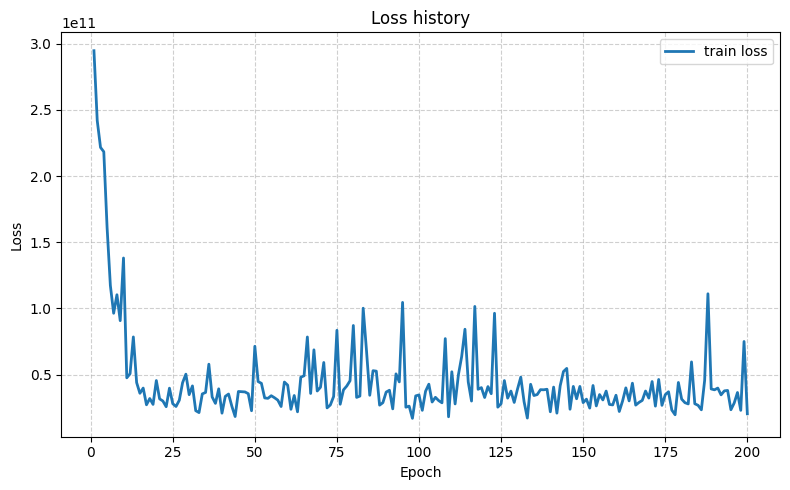

20365166601.187576


In [1]:
from typing import Tuple

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

class MyModel:

    def __init__(self,
                 learning_rate: float,
                 n_iter: int,
                 batch_size: int|None = None,
                 l1: float|None = None,
                 l2: float|None = None,
                 ):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.batch_size = batch_size
        self.l1 = l1
        self.l2 = l2
        self.fitted = False
        self.norm_params = None
        self.coefficent = None
        self.intercept = None
        self.loss_history = []

    def __str__(self):
        return f"MyModel (fitted={self.fitted}, coef+interc={self.coefficent}+{self.intercept})"

    def fit(self, x_train, y_train, scale_data=True, random_state=42):
        if scale_data:
            x_train, self.norm_params = self.scaler(data=x_train)

        self.init_start_params(x_train, y_train)

        if random_state is not None:
            np.random.seed(random_state)

        for _ in tqdm(range(int(self.n_iter)), desc="Training", unit="iter"):
            x_batch, y_batch = self.get_batch_data(x_train=x_train, y_train=y_train)
            self.update_coefficents(x_batch=x_batch, y_batch=y_batch)
            self.loss_history.append(self.calculate_loss(x_data=x_batch,
                                                     y_data=y_batch))

        self.fitted = True
        return {"W": self.coefficent, "intercept": self.intercept}

    def predict(self, data: pd.DataFrame):
        if self.norm_params is not None:
            data = (data - self.norm_params["mean"]) / self.norm_params["std"]
        y_prediction = data @ self.coefficent + self.intercept
        return y_prediction

    def scaler(self, data: pd.DataFrame):
        norm_params = pd.DataFrame({
                                    "mean": data.mean(),
                                    "std": data.std(ddof=0),
                                    })
        data_norm = (data - norm_params["mean"]) / norm_params["std"]
        return data_norm, norm_params

    def init_start_params(self, x_data: pd.DataFrame, y_data: pd.Series):
        self.coefficent = np.zeros(x_data.shape[1], dtype=float)
        self.intercept = 0
        self.loss_history.append(self.calculate_loss(x_data=x_data,
                                                     y_data=y_data))

    def calculate_loss(self, x_data, y_data):
        y_prediction = x_data @ self.coefficent + self.intercept
        loss = sum((y_prediction - y_data) ** 2) / len(x_data)
        return loss

    def get_batch_data(self, x_train: pd.DataFrame, y_train: pd.Series) -> Tuple[pd.DataFrame, pd.Series]:
        if self.batch_size is not None:
            idx = x_train.sample(n=self.batch_size).index
            x_batch = x_train.loc[idx]
            y_batch = y_train.loc[idx]
            return x_batch, y_batch
        return x_train, y_train

    def update_coefficents(self, x_batch: pd.DataFrame, y_batch: pd.Series):
        y_prediction = x_batch @ self.coefficent + self.intercept
        errors = y_prediction - y_batch
        gradients = self.calculate_gradients(x_batch, errors)
        grad_intercept = errors.mean()

        self.coefficent -= self.learning_rate * gradients
        self.intercept -= self.learning_rate * grad_intercept

    def calculate_gradients(self, x_batch: pd.DataFrame, errors):
        gradients = x_batch.to_numpy().T @ errors / len(x_batch)
        if self.l1 is not None:
            gradients += self.l1 * np.sign(self.coefficent)
        if self.l2 is not None:
            gradients += self.l2 * self.coefficent
        return gradients

    def plot_loss_history(self, title="Loss history", figsize=(8, 5), without_init_loss=True):
        losses = self.loss_history
        if without_init_loss and len(losses) > 1:
            losses = losses[1:]

        epochs = range(1, len(losses) + 1)

        plt.figure(figsize=figsize)
        plt.plot(epochs, losses, linewidth=2, label="train loss")
        plt.title(title)
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.legend()
        plt.tight_layout()
        plt.show()



if __name__ == "__main__":
    training_df = pd.read_excel('/content/predict_house_price_training_data.xlsx')

    target_variable_name = 'Целевая.Цена'
    y_train = training_df[target_variable_name]
    x_train = training_df.drop(target_variable_name, axis=1)

    lin_model = MyModel(learning_rate=0.1,
                                n_iter=200,
                                batch_size=200,
                                l1 = 0.01,
                                l2 = 0.01,
                                )

    print(lin_model)

    lin_model.fit(x_train=x_train, y_train=y_train, scale_data=True)

    print(lin_model)

    lin_model.plot_loss_history()

    print(lin_model.loss_history[-1])
